Multiple linear regression in Python

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [15]:
data = {
    "Study_Hours" : [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance"  : [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignment_Score" : [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_Marks" : [42, 48, 54, 61, 67, 73, 81, 89]
}

df = pd.DataFrame(data)

In [16]:
x = df[["Study_Hours","Attendance","Assignment_Score"]]
y = df["Final_Marks"]

In [17]:
model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

print("Intercept : ", model.intercept_)

Intercept :  -28.31652806652808


In [18]:
coefficient_table = pd.DataFrame({
    "Feature" : x.columns,
    "Coefficient" : model.coef_
})

In [19]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.131410
1        Attendance     0.657051
2  Assignment_Score     0.608108


In [20]:
new_student = pd.DataFrame({
    "Study_Hours" : [6],
    "Attendance" : [82],
    "Assignment_Score" : [72]
})

In [21]:
prediction = model.predict(new_student)

print("Predicted final mark : ", prediction[0])

Predicted final mark :  70.13392238392238


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [23]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  -28.31652806652808
Slope :  0.13141025641025642
Actual values :  [48 73]
Predicted values :  [41.77477477 48.23198198 53.47297297 61.1463964  67.6036036  73.4527027
 80.51801802 88.79954955]


In [25]:
print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [2, 8]

ValueError: x and y must be the same size

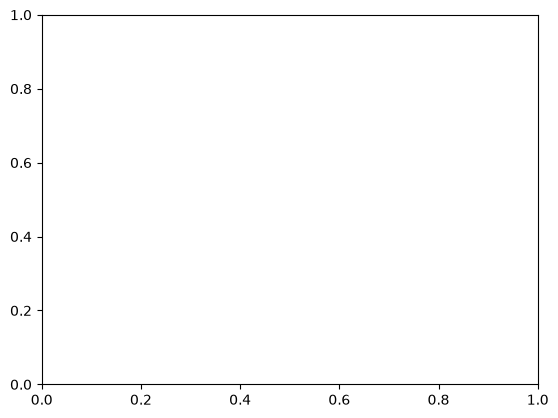

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()

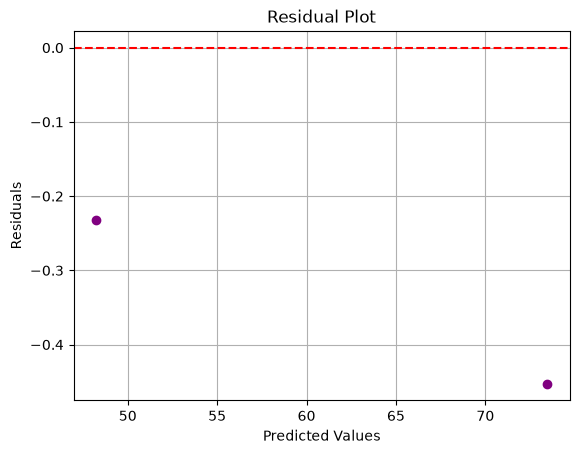

In [35]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

After Applying Ridge